### 主題模型

### 使用主題模型找出在伊朗戰爭中，大家重點討論的主題

In [1]:
import re
import time 
from functools import reduce
from collections import Counter
from pprint import pprint
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import jieba
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel
from gensim.models.ldamulticore import LdaMulticore
from gensim.matutils import corpus2csc, corpus2dense, Sparse2Corpus

import pyLDAvis
import pyLDAvis.gensim_models

In [2]:
BASE_DIR = Path.cwd()
DICT_DIR = BASE_DIR.parent / 'dict'
DATA_DIR = BASE_DIR.parent / 'data'

pd.set_option('display.max_colwidth', 120)
plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
font_path = BASE_DIR / 'font.ttf'
if font_path.exists():
    fm.fontManager.addfont(str(font_path))
    font_name = fm.FontProperties(fname=str(font_path)).get_name()
else:
    font_name = 'Arial Unicode MS'

plt.rcParams['font.sans-serif'] = [font_name]
plt.rcParams['axes.unicode_minus'] = False
print(f'using font: {font_name}')

using font: Noto Sans TC


#### 使用截至04/10的資料

In [4]:
ptt = pd.read_csv("../data/ptt_iran_20260301_0410_full.csv")  # 匯資料
ptt.head(3)

,system_id,artUrl,artTitle,artDate,artPoster,artCatagory,artContent,artComment,insertedDate,dataSource
0,1,https://www.ptt.cc/bbs/Military/M.1775823165.A.7A5.html,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,2026-04-10 20:12:41,wysptt,Military,新聞出處：\r\nhttps://www.cna.com.tw/news/aopl/202604100193.aspx\r\n\r\n新聞內容摘要：\r\n（中央社新德里10日綜合外電報導）美國與伊朗將於11日在巴基斯坦首都伊斯蘭馬...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""tony121010"", ""cmtContent"": "": 那麼多石油王，他們會出啦"", ""cmtDate"": ""2026-04-10 20:13:00""}, {""...",2026-04-13 22:25:19,ptt
1,2,https://www.ptt.cc/bbs/Military/M.1775809255.A.D32.html,[情報] 幾則關於伊朗戰爭的民調,2026-04-10 16:20:52,jimmy5680,Military,https://x.com/NateSilver538/status/2039839743404363863\r\n根據Nate Silver的統整各間民調，\r\n可見美國民眾對伊朗戰爭的支持度持續下滑\r\nhttps://pb...,"[{""cmtStatus"": ""推"", ""cmtPoster"": ""MarchelKaton"", ""cmtContent"": "": 川普還嗆右派名嘴不是MAGA自己人了"", ""cmtDate"": ""2026-04-10 17:53:...",2026-04-13 22:25:19,ptt
2,3,https://www.ptt.cc/bbs/Military/M.1775807658.A.5CA.html,[分享] 大西洋期刊：中國從伊朗戰爭學到什麼,2026-04-10 15:54:15,jimmy5680,Military,大西洋期刊，我對這篇文章不予置評，僅供參考\r\nhttps://x.com/shustry/status/2042217021010571332\r\nhttps://t.co/e88nkwJ8hQ\r\n\r\n中國從伊朗戰爭中...,"[{""cmtStatus"": ""→"", ""cmtPoster"": ""jinkela1"", ""cmtContent"": "": 可寫一整篇回文 但總而言之 台灣情況和伊朗天差地別"", ""cmtDate"": ""2026-04-10 15:...",2026-04-13 22:25:20,ptt


#### 進行為ptt文章設計的文字清除

In [5]:
custom_words = [
    '防衛隊', '革命衛隊', '無人機', '核設施', '哈瑪斯', '真主黨', '中東',
    '大馬士革', '德黑蘭', '哈梅內伊', '哈米尼', '霍爾木茲海峽',
    '荷姆茲海峽', '荷莫茲海峽','彈道飛彈','革命衛隊'
]

synonyms = {
    '哈梅內伊': '哈米尼',
    '霍爾木茲': '荷姆茲',
    '荷莫茲': '荷姆茲',
    '阿川': '川普',
    '川皇': '川普',
}

manual_stopwords = {
    # --- 原始清單 ---
    '-----', '----', '連結', '嘖嘖', '醒醒', '裝睡', '衛生紙', '乳摸', '高潮',
    '新聞', '內文', '備註', '刪除', '完整', '轉載', '編輯', '張貼', '署名',
    '文章', '標題', '報導', '八卦', '看板', '作者', '時間', '來源', '內容',
    '媒體', '情況', '問題', '如題', '原因', '網址', '發信', '實業', 'cc',
    'ptt', 'gossiping', 'www', 'com', 'https', 'http', 'share', 'url', 'index',
    'html', 'bbs', 'status', '表示', '行動', '國家', '當作', '出現', '晚間',
    '政府', '目前', '請放', '最後', '違者', '未滿', '繁體', '中文字', '水桶',
    '一天', '以天', '單位', '網友', '點擊', '情報', '分享', '問卦', '討論',
    '心得', '爆卦', '認為', '進行', '持續', '指出', '顯示', '要求', '造成', '提供',
    '使用', '希望', '需要', '提出', '決定', '發生', '透過', '告訴', '現在', '相關', 
    '這場', '一名', '這種', '這一', '正在', '包括', '原文', '一直', '一堆', '有沒有', '看到','一道',

    # --- 新增：報導與描述語境詞 (避免干擾軍事核心語意) ---
    '消息', '影片', '影像', '畫面', '回應', '公開', '影響', '證實', '傳出', '報導',
    '直接', '繼續', '擁有', '重要', '並未', '完全', '試圖', '方面', '過去', '可能', 
    '似乎', '甚至', '其實', '覺得', '應該', '只是', '感覺', '發現', '真的', '當時',
    '今天', '昨天', '一些', '以及', '的話', '一個', '一樣', '一般', '一次', '留言',

    # --- 新增：常見副詞與結構詞 (LDA 雜訊) ---
    '比較', '已經', '特別', '非常', '或是', '之後', '結果', '大家', '不可', '一點'
}

jieba.set_dictionary(str(DICT_DIR / 'dict.txt'))
jieba.load_userdict(str(DICT_DIR / 'user_dict.txt'))
for word in custom_words:
    jieba.add_word(word)

stopwords = []
for stopword_file in [DICT_DIR / 'stopwords.txt', DICT_DIR / 'text_stopwords.txt']:
    with open(stopword_file, encoding='utf-8') as f:
        stopwords.extend([line.strip() for line in f if line.strip()])
stopwords = set(stopwords) | manual_stopwords


def clean_ptt_text(text):
    text = str(text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'※\s*(發信站|文章網址|編輯).*', '', text)
    text = re.sub(r'引述《.*?》之銘言', '', text)
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'^[>:]\s*', '', text, flags=re.MULTILINE)
    text = re.sub(r'[a-zA-Z0-9]+', '', text)
    text = re.sub(r'[-/=_~]{2,}', '', text)
    text = re.sub(r'[^\u4e00-\u9fa5\n]+', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


def getToken(text):
    tokens = []
    for word in jieba.lcut(text):
        word = synonyms.get(word, word).strip()
        if len(word) >= 2 and word not in stopwords:
            tokens.append(word)
    return tokens


def prepare_ptt_documents(df, drop_missing_label=True):
    data = df[['artUrl', 'artTitle', 'artContent', 'artCatagory', 'artDate']].copy()
    subset = ['artTitle', 'artContent'] + (['artCatagory'] if drop_missing_label else [])
    data = data.dropna(subset=subset)
    data = data.drop_duplicates(subset='artUrl').copy()
    data['artDate'] = pd.to_datetime(data['artDate'], errors='coerce')
    data['title_clean'] = data['artTitle'].map(clean_ptt_text)
    data['content_clean'] = data['artContent'].map(clean_ptt_text)
    data['content'] = (data['title_clean'] + ' ' + data['content_clean']).str.strip()
    data['words'] = data['content'].apply(getToken)
    data = data[data['words'].str.len() > 0].copy()
    return data


def plot_confusion(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=plt.cm.Blues, cbar=False, ax=ax)
    ax.set(
        xlabel='Pred',
        ylabel='True',
        xticklabels=classes,
        yticklabels=classes,
        title=title,
    )
    plt.yticks(rotation=0)
    plt.show()
    return cm

Building prefix dict from C:\Users\justi\OneDrive\文件\中山碩士\社媒\Social_Network_Analysis_Group_3-main\groupwork2\dict\dict.txt ...
Loading model from cache C:\Users\justi\AppData\Local\Temp\jieba.u8028ad36b404e2a685691e04a294fe4e.cache
Loading model cost 0.371 seconds.
Prefix dict has been built successfully.


In [6]:
ptt_clean = prepare_ptt_documents(ptt)

ptt_clean.head(3)

,artUrl,artTitle,artContent,artCatagory,artDate,title_clean,content_clean,content,words
0,https://www.ptt.cc/bbs/Military/M.1775823165.A.7A5.html,[新聞] 保護伊朗人員前來 巴基斯坦空軍闢安全,新聞出處：\r\nhttps://www.cna.com.tw/news/aopl/202604100193.aspx\r\n\r\n新聞內容摘要：\r\n（中央社新德里10日綜合外電報導）美國與伊朗將於11日在巴基斯坦首都伊斯蘭馬...,Military,2026-04-10 20:12:41,保護伊朗人員前來 巴基斯坦空軍闢安全,新聞出處 新聞內容摘要 中央社新德里日綜合外電報導 美國與伊朗將於日在巴基斯坦首都伊斯蘭馬巴德舉行 萬眾矚目的談判 外媒披露 巴基斯坦空軍出動大批各式軍機到波斯灣空域 保護伊朗代表 團前來赴會 今日印度報 報導 巴基斯坦為確保安全而...,保護伊朗人員前來 巴基斯坦空軍闢安全 新聞出處 新聞內容摘要 中央社新德里日綜合外電報導 美國與伊朗將於日在巴基斯坦首都伊斯蘭馬巴德舉行 萬眾矚目的談判 外媒披露 巴基斯坦空軍出動大批各式軍機到波斯灣空域 保護伊朗代表 團前來赴會 ...,"[保護, 伊朗, 人員, 前來, 巴基斯坦, 空軍, 安全, 出處, 摘要, 中央社, 新德里, 綜合, 外電, 美國, 伊朗, 將於日, 巴基斯坦, 首都, 伊斯蘭, 巴德, 舉行, 萬眾矚目, 談判, 外媒, 披露, 巴基斯坦,..."
1,https://www.ptt.cc/bbs/Military/M.1775809255.A.D32.html,[情報] 幾則關於伊朗戰爭的民調,https://x.com/NateSilver538/status/2039839743404363863\r\n根據Nate Silver的統整各間民調，\r\n可見美國民眾對伊朗戰爭的支持度持續下滑\r\nhttps://pb...,Military,2026-04-10 16:20:52,幾則關於伊朗戰爭的民調,根據 的統整各間民調 可見美國民眾對伊朗戰爭的支持度持續下滑 皮尤民調 追蹤美國民眾對以色列和納坦雅胡的支持度 顯示美國民眾越來越厭惡以色列和納坦雅胡 天空新聞 民調顯示從去年年底到現在 英國民眾認為美國是世界上的負面力量的比例達 ...,幾則關於伊朗戰爭的民調 根據 的統整各間民調 可見美國民眾對伊朗戰爭的支持度持續下滑 皮尤民調 追蹤美國民眾對以色列和納坦雅胡的支持度 顯示美國民眾越來越厭惡以色列和納坦雅胡 天空新聞 民調顯示從去年年底到現在 英國民眾認為美國是世...,"[幾則, 伊朗, 戰爭, 民調, 統整, 各間, 民調, 美國, 民眾, 伊朗, 戰爭, 支持度, 下滑, 民調, 追蹤, 美國, 民眾, 以色列, 納坦雅胡, 支持度, 美國, 民眾, 越來越, 厭惡, 以色列, 納坦雅胡, 天空..."
2,https://www.ptt.cc/bbs/Military/M.1775807658.A.5CA.html,[分享] 大西洋期刊：中國從伊朗戰爭學到什麼,大西洋期刊，我對這篇文章不予置評，僅供參考\r\nhttps://x.com/shustry/status/2042217021010571332\r\nhttps://t.co/e88nkwJ8hQ\r\n\r\n中國從伊朗戰爭中...,Military,2026-04-10 15:54:15,大西洋期刊 中國從伊朗戰爭學到什麼,大西洋期刊 我對這篇文章不予置評 僅供參考 中國從伊朗戰爭中學到了什麼 對台灣實施封鎖 對全球經濟造成的衝擊 將比伊朗封鎖荷姆茲海峽更為嚴重 中國可以從這場伊朗戰爭中學到許多 美國劃下的紅線與期限 即使伴隨著種族滅絕的威 脅 也可能...,大西洋期刊 中國從伊朗戰爭學到什麼 大西洋期刊 我對這篇文章不予置評 僅供參考 中國從伊朗戰爭中學到了什麼 對台灣實施封鎖 對全球經濟造成的衝擊 將比伊朗封鎖荷姆茲海峽更為嚴重 中國可以從這場伊朗戰爭中學到許多 美國劃下的紅線與期限...,"[大西洋, 期刊, 中國, 伊朗, 戰爭, 學到, 大西洋, 期刊, 這篇, 不予置評, 參考, 中國, 伊朗, 戰爭, 中學, 台灣, 實施, 封鎖, 全球, 經濟, 衝擊, 將比, 伊朗, 封鎖, 荷姆茲海峽, 嚴重, 中國, ..."


#### 只保留'content_clean', 'artUrl', 'artCatagory', 'artDate','words'

In [7]:
ptt_clean = ptt_clean.loc[:,['content_clean', 'artUrl', 'artCatagory', 'artDate','words']]

ptt_clean.head(3)

,content_clean,artUrl,artCatagory,artDate,words
0,新聞出處 新聞內容摘要 中央社新德里日綜合外電報導 美國與伊朗將於日在巴基斯坦首都伊斯蘭馬巴德舉行 萬眾矚目的談判 外媒披露 巴基斯坦空軍出動大批各式軍機到波斯灣空域 保護伊朗代表 團前來赴會 今日印度報 報導 巴基斯坦為確保安全而...,https://www.ptt.cc/bbs/Military/M.1775823165.A.7A5.html,Military,2026-04-10 20:12:41,"[保護, 伊朗, 人員, 前來, 巴基斯坦, 空軍, 安全, 出處, 摘要, 中央社, 新德里, 綜合, 外電, 美國, 伊朗, 將於日, 巴基斯坦, 首都, 伊斯蘭, 巴德, 舉行, 萬眾矚目, 談判, 外媒, 披露, 巴基斯坦,..."
1,根據 的統整各間民調 可見美國民眾對伊朗戰爭的支持度持續下滑 皮尤民調 追蹤美國民眾對以色列和納坦雅胡的支持度 顯示美國民眾越來越厭惡以色列和納坦雅胡 天空新聞 民調顯示從去年年底到現在 英國民眾認為美國是世界上的負面力量的比例達 ...,https://www.ptt.cc/bbs/Military/M.1775809255.A.D32.html,Military,2026-04-10 16:20:52,"[幾則, 伊朗, 戰爭, 民調, 統整, 各間, 民調, 美國, 民眾, 伊朗, 戰爭, 支持度, 下滑, 民調, 追蹤, 美國, 民眾, 以色列, 納坦雅胡, 支持度, 美國, 民眾, 越來越, 厭惡, 以色列, 納坦雅胡, 天空..."
2,大西洋期刊 我對這篇文章不予置評 僅供參考 中國從伊朗戰爭中學到了什麼 對台灣實施封鎖 對全球經濟造成的衝擊 將比伊朗封鎖荷姆茲海峽更為嚴重 中國可以從這場伊朗戰爭中學到許多 美國劃下的紅線與期限 即使伴隨著種族滅絕的威 脅 也可能...,https://www.ptt.cc/bbs/Military/M.1775807658.A.5CA.html,Military,2026-04-10 15:54:15,"[大西洋, 期刊, 中國, 伊朗, 戰爭, 學到, 大西洋, 期刊, 這篇, 不予置評, 參考, 中國, 伊朗, 戰爭, 中學, 台灣, 實施, 封鎖, 全球, 經濟, 衝擊, 將比, 伊朗, 封鎖, 荷姆茲海峽, 嚴重, 中國, ..."


#### 文章類別為Military和Gossiping兩種

In [8]:
ptt_clean['artCatagory'].unique()

array(['Military', 'Gossiping'], dtype=object)

In [9]:
ptt_clean['artCatagory'].value_counts()

artCatagory
Gossiping    2616
Military      931
Name: count, dtype: int64

#### 軍事板前詞頻前100關鍵字

In [10]:
military_cnt = ptt_clean.loc[ptt_clean['artCatagory'] == 'Military',:]['words'].explode().value_counts().head(100)
military_cnt.index

Index(['伊朗', '美國', '川普', '以色列', '戰爭', '攻擊', '美軍', '飛彈', '官員', '目標', '軍事', '打擊',
       '總統', '無人機', '部隊', '談判', '政權', '空襲', '發動', '中國', '設施', '支持', '中東', '能力',
       '人士', '石油', '發射', '安全', '荷姆茲海峽', '真主黨', '德黑蘭', '地區', '革命衛隊', '衝突', '協議',
       '結束', '威脅', '基地', '停火', '作戰', '伊拉克', '摧毀', '計畫', '黎巴嫩', '伊斯蘭', '能源',
       '達成', '系統', '領袖', '海峽', '哈米尼', '經濟', '武器', '地面', '無法', '聯合', '全球', '國際',
       '防空', '接受', '基礎', '戰略', '烏克蘭', '轟炸', '海灣', '俄羅斯', '人員', '外交', '國防軍',
       '記者', '聲稱', '盟友', '武裝', '船隻', '白宮', '海軍', '彈道飛彈', '歐洲', '政治', '襲擊',
       '彈藥', '國會', '公司', '領導人', '軍方', '主要', '空軍', '警告', '知道', '遭到', '長期',
       '波斯灣', '聲明', '削弱', '組織', '專家', '之間', '封鎖', '大規模', '準備'],
      dtype='object', name='words')

#### 八卦板前詞頻前100關鍵字

In [11]:
gossiping_cnt = ptt_clean.loc[ptt_clean['artCatagory'] == 'Gossiping',:]['words'].explode().value_counts().head(100)
gossiping_cnt.index

Index(['伊朗', '美國', '川普', '以色列', '戰爭', '中國', '美軍', '攻擊', '台灣', '飛彈', '中東', '軍事',
       '總統', '無人機', '記者', '石油', '目標', '談判', '打擊', '基地', '政權', '世界', '哈米尼',
       '設施', '知道', '發動', '領袖', '導彈', '中共', '支持', '部隊', '革命衛隊', '全球', '安全',
       '能源', '官員', '國際', '俄羅斯', '空襲', '海峽', '根本', '武器', '德黑蘭', '能力', '襲擊',
       '美以', '系統', '地區', '無法', '經濟', '威脅', '投降', '結束', '轟炸', '地面', '封鎖', '摧毀',
       '防空', '美元', '烏克蘭', '衝突', '協議', '伊斯蘭', '人士', '核武', '荷莫茲海峽', '油價', '發射',
       '停火', '荷姆茲海峽', '戰略', '海軍', '高層', '警告', '報復', '達成', '綜合', '接受', '至少',
       '政治', '卡達', '準備', '人員', '天然氣', '作戰', '制裁', '空軍', '波斯灣', '宣布', '日本',
       '強調', '原油', '專家', '伊拉克', '阿拉伯', '民眾', '船隻', '關係', '公司', '遭到'],
      dtype='object', name='words')

#### 自定義主題字典:分為6個不同維度

In [12]:
custom_topic_word = {
    "中東衝突核心": [
        "伊朗", "以色列", "中東", "德黑蘭", "黎巴嫩", "伊拉克", "敘利亞", "加薩", "波斯灣", "哈瑪斯"
    ],
    "軍事行動與武裝": [
        "戰爭", "攻擊", "飛彈", "無人機", "空襲", "彈道飛彈", "打擊", "發射", "軍事", 
        "基地", "摧毀", "武器", "防空系統", "轟炸", "導彈", "地面行動", "國防軍", "彈道", "武裝", "報復"
    ],
    "政治領袖與組織": [
        "川普", "美軍", "哈米尼", "革命衛隊", "真主黨", "總統", "政權", "領袖", "中共", "盟友", "白宮"
    ],
    "地緣政治與大國": [
        "美國", "中國", "台灣", "俄羅斯", "烏克蘭", "全球", "國際", "戰略", "外交", "歐盟", "日本"
    ],
    "能源與經濟衝擊": [
        "石油", "能源", "油價", "經濟", "荷姆茲海峽", "天然氣", "海峽", "封鎖", "美元", "制裁", "原油"
    ],
    "外交與停火談判": [
        "談判", "協議", "停火", "結束", "達成", "要求", "安全", "接受", "支持", "聯合國", "聲明"
    ]
}

#### 統整出關鍵字庫

In [13]:
vocabularies = np.unique(reduce(lambda x, y: x + y, custom_topic_word.values()))

In [14]:
vocabularies

array(['中共', '中國', '中東', '以色列', '伊拉克', '伊朗', '俄羅斯', '停火', '全球', '制裁',
       '加薩', '協議', '原油', '台灣', '哈瑪斯', '哈米尼', '國防軍', '國際', '地面行動', '基地',
       '報復', '外交', '天然氣', '安全', '封鎖', '導彈', '川普', '彈道', '彈道飛彈', '德黑蘭',
       '戰爭', '戰略', '打擊', '接受', '摧毀', '支持', '攻擊', '政權', '敘利亞', '日本', '歐盟',
       '武器', '武裝', '油價', '波斯灣', '海峽', '烏克蘭', '無人機', '發射', '白宮', '盟友',
       '真主黨', '石油', '空襲', '結束', '經濟', '總統', '美元', '美國', '美軍', '聯合國', '聲明',
       '能源', '荷姆茲海峽', '要求', '談判', '軍事', '轟炸', '達成', '防空系統', '革命衛隊', '領袖',
       '飛彈', '黎巴嫩'], dtype='<U5')

#### 產出 DTM_df 表格，橫列為文章、直欄為關鍵字，格點數值則代表該字出現次數。

In [15]:
ptt_corpus = ptt_clean['words'].map(" ".join)
vectorizer = CountVectorizer(vocabulary=vocabularies)
ptt_matrix = vectorizer.fit_transform(ptt_corpus)

ptt_matrix = ptt_matrix.toarray()
feature_names = vectorizer.get_feature_names_out()

DTM_df = pd.DataFrame(columns = feature_names, data = ptt_matrix)
DTM_df

,中共,中國,中東,以色列,伊拉克,伊朗,俄羅斯,停火,全球,制裁,...,要求,談判,軍事,轟炸,達成,防空系統,革命衛隊,領袖,飛彈,黎巴嫩
0,0,0,0,1,0,8,0,0,0,0,...,0,2,0,0,0,0,0,0,0,0
1,0,1,0,2,0,3,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,12,0,0,0,14,0,2,8,0,...,0,1,2,0,0,0,0,1,0,0
3,0,0,0,4,0,4,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,1,0,1,2,0,9,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3542,0,0,1,1,0,7,0,0,0,0,...,0,0,5,0,0,0,1,0,2,0
3543,0,0,0,2,0,4,0,0,0,0,...,0,0,3,0,0,0,0,0,0,0
3544,0,0,0,1,0,5,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3545,0,0,0,0,0,4,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### 主題統計

In [16]:
df_count = pd.DataFrame({})

# k 是主題名稱，v 是這個主題下的詞彙list
for k, v in custom_topic_word.items():
    idx = np.isin(
        feature_names,
        v
    )
    df_count[f'topic_{k}'] = ptt_matrix[:, idx].sum(axis=1)
    
df_count

,topic_中東衝突核心,topic_軍事行動與武裝,topic_政治領袖與組織,topic_地緣政治與大國,topic_能源與經濟衝擊,topic_外交與停火談判
0,12,1,0,2,0,5
1,5,3,0,7,0,1
2,14,13,17,55,28,5
3,8,2,0,0,0,0
4,17,6,4,4,0,2
...,...,...,...,...,...,...
3542,11,18,2,3,1,1
3543,6,3,2,2,0,0
3544,6,1,0,4,0,0
3545,4,0,0,0,0,0


#### 計算文章的主題權重 ($\theta$)

In [17]:
thetas = df_count.div(
    df_count.sum(axis=1),
    axis=0
)
thetas.head()

,topic_中東衝突核心,topic_軍事行動與武裝,topic_政治領袖與組織,topic_地緣政治與大國,topic_能源與經濟衝擊,topic_外交與停火談判
0,0.600000,0.050000,0.000000,0.100000,0.000000,0.250000
1,0.312500,0.187500,0.000000,0.437500,0.000000,0.062500
2,0.106061,0.098485,0.128788,0.416667,0.212121,0.037879
3,0.800000,0.200000,0.000000,0.000000,0.000000,0.000000
4,0.515152,0.181818,0.121212,0.121212,0.000000,0.060606


#### 轉換為清單格式

In [18]:
docs = ptt_clean['words'].to_list()
docs[0]

['保護',
 '伊朗',
 '人員',
 '前來',
 '巴基斯坦',
 '空軍',
 '安全',
 '出處',
 '摘要',
 '中央社',
 '新德里',
 '綜合',
 '外電',
 '美國',
 '伊朗',
 '將於日',
 '巴基斯坦',
 '首都',
 '伊斯蘭',
 '巴德',
 '舉行',
 '萬眾矚目',
 '談判',
 '外媒',
 '披露',
 '巴基斯坦',
 '空軍',
 '出動',
 '大批',
 '軍機',
 '波斯灣',
 '空域',
 '保護',
 '伊朗',
 '代表',
 '前來',
 '赴會',
 '今日',
 '印度',
 '巴基斯坦',
 '確保',
 '安全',
 '開闢',
 '空中',
 '安全',
 '走廊',
 '專家',
 '稱為',
 '鋼鐵',
 '護航',
 '除將',
 '伊斯蘭',
 '巴德',
 '空域',
 '防護',
 '得密',
 '透風',
 '巴基斯坦',
 '加強',
 '南部',
 '西部',
 '空防',
 '伊朗',
 '空軍',
 '幾已',
 '美國',
 '以色列',
 '摧毀',
 '殆盡',
 '巴基斯坦',
 '部署',
 '大量',
 '軍機',
 '伊朗',
 '上空',
 '波斯灣',
 '撐起',
 '防護',
 '保護',
 '伊朗',
 '代表團',
 '飛航',
 '追蹤',
 '數據',
 '巴基斯坦',
 '戰機',
 '伊朗',
 '港市',
 '阿巴斯',
 '附近',
 '負責',
 '護送',
 '載有',
 '伊朗',
 '代表團',
 '飛機',
 '前往',
 '伊斯蘭',
 '巴德',
 '這段',
 '小時',
 '航程',
 '巴基斯坦',
 '空軍',
 '出動',
 '伊留申',
 '空中',
 '加油機',
 '延長',
 '戰機',
 '滯空',
 '派出',
 '空中',
 '預警機',
 '監控',
 '巴基斯坦',
 '波斯灣',
 '空域',
 '巴基斯坦',
 '出動',
 '這麼多',
 '架次',
 '各型',
 '飛機',
 '燃料費',
 '保養費',
 '消耗',
 '想必',
 '驚人',
 '巴國',
 '大手筆',
 '想攬',
 '和平',
 '停戰',
 '談判',
 '主場',
 '想爭',

#### 特徵篩選

In [19]:
dictionary = Dictionary(docs)

dictionary.filter_extremes(no_below=5, no_above=0.8)
print(dictionary)

Dictionary<8352 unique tokens: ['上空', '中央社', '主場', '人員', '今日']...>


#### Word-to-ID 映射

In [20]:
for idx, (k, v) in enumerate(dictionary.token2id.items()):
    print(f"{k}: {v}")
    if idx > 10:
        break

上空: 0
中央社: 1
主場: 2
人員: 3
今日: 4
代表: 5
代表團: 6
以色列: 7
伊斯蘭: 8
保護: 9
停戰: 10
出動: 11


In [21]:
pprint(" ".join(ptt_clean['words'].iloc[600]))

('專訪 伊朗 面臨 一場 革命 華爾街日報 專訪 伊朗 處於 一場 革命 邊緣 歷史 學者 阿里 安薩里 伊朗 當前 政權 面臨 前所未有 危機 長達 '
 '傳統 不斷 建立 法治 體系 奮鬥 專家 伊朗 不可能 政權 更迭 不可能 一月 大規模 抗議 政權 掌握 武力 願意 對領 導人 暴徒 空襲 無法 '
 '空中 打擊 推翻 政權 相信 政治學 阿里 安薩里 看法 堅信 漢娜 阿倫 革命 不可能 後則 避免 安薩里 教授 蘇格蘭 安德魯 大學 歷史學家 負責 '
 '該校 伊朗 研究所 出版 伊朗 一書 了解 現代史 最佳 入門 讀物 擔心 社會 科學家 國際 關係 專家 依賴 分析 模板 看不到 伊朗 內部 事情 '
 '絕大 多數 掙扎 政治體制 備受 憎恨 經濟 體制 無法 滿足 需求 一段 談中 薪水 無法 維持 生活 需求 環境 危機 地下水 抽乾 面臨 國際 '
 '危機 這說 還算 委婉 想到 一場 危機 伊斯蘭 共和國 面臨 安薩里 強大 穩定 不可能 強大 穩定 每隔 幾年 反抗 規模 之大 政權 視為 生死 '
 '存亡 挑戰 安薩里 估計 支持 政權 人口 相信 戰爭 擊敗 美國 停頓 一下 做到 這位 教授 強調 審慎 無法 確定 政權 倒台 認同 一月 抗議 '
 '運動 徹底 鎮壓 說法 美國 以色列 創造 契機 政權 大規模 屠殺 實際 適得其反 宣稱 死亡 鎮壓 成功 但當 隨機 方式 殺害 同胞 病床 開槍 '
 '激起 難以 壓制 憤怒 空襲 學生 重新 抗議 將此 中國 天安門 廣場 屠殺 相比 恰當 有多種 北京 能夠 民眾 好處 政治 壓制 經濟 成功 收買 '
 '正要 成為 大國 伊朗 政權 唯一 伊朗 天堂 開心 聽到 伊朗 殘酷 鎮壓 抗議 抗議 運動 上街 值得 射殺 突然 一月 這股 以往 反抗 浪潮 '
 '視角 拉遠 抗議 手段 加速 一波接 一波 反覆 抗議 傾向 努力 爭取 自由 憲法 革命 遺產 革命 伊朗 贏得 英美 傳統 自由 憲法 建立 法治 '
 '理想 尚未 實踐 安薩里 著作 伊斯蘭 革命 奪走 聚光燈 革命 政治 思想 主義 深遠 傳統 一種 活生生 伊朗 新建 工程 真正 現代化 機構 阿亞 '
 '圖拉們 沙阿手 繼承 下來 教科書 伊斯蘭 革命 始於 伊特 拉拉 特報 發表

In [22]:
dictionary.doc2bow(ptt_clean['words'].iloc[600])[:10]

[(7, 1),
 (8, 8),
 (23, 2),
 (24, 2),
 (43, 1),
 (47, 16),
 (51, 1),
 (52, 2),
 (55, 1),
 (73, 1)]

#### 把所有文件轉換為Bag-of-Words

In [23]:
corpus = [dictionary.doc2bow(doc) for doc in docs]

#### 尋找最佳主題數

In [24]:
t0 = time.time()

topic_num_list = np.arange(2, 10)
result = {"topic_num":[], "perplexity":[], "pmi":[]}
model_set = dict()


for topic_num in topic_num_list:
    # perplexity
    model = LdaModel(
        corpus = corpus,
        num_topics = topic_num ,
        id2word=dictionary,
        random_state = 1500,
        passes=5 # 訓練次數
        )
    
    loss = model.log_perplexity(corpus)
    pmi = CoherenceModel(model=model, texts=docs, coherence='c_npmi').get_coherence()
    perplexity = np.exp(-1. * loss)
    
    # model_set[f'k_{topic_num}'] = model
    
    result['topic_num'].append(topic_num)
    result['perplexity'].append(perplexity)
    result['pmi'].append(pmi)
    
print(f"花費時間: {time.time() - t0} sec")

花費時間: 252.02141427993774 sec


In [25]:
result = pd.DataFrame(result)
result

,topic_num,perplexity,pmi
0,2,2350.120787,-0.005122
1,3,2244.105597,0.007852
2,4,2259.231106,0.018383
3,5,2222.488965,0.021815
4,6,2207.302981,0.021816
5,7,2211.691337,0.018284
6,8,2239.496802,-0.014895
7,9,2199.312463,-0.001492


D:\Anaconda\envs\nlp_env\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
D:\Anaconda\envs\nlp_env\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
D:\Anaconda\envs\nlp_env\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


<Axes: xlabel='topic_num'>

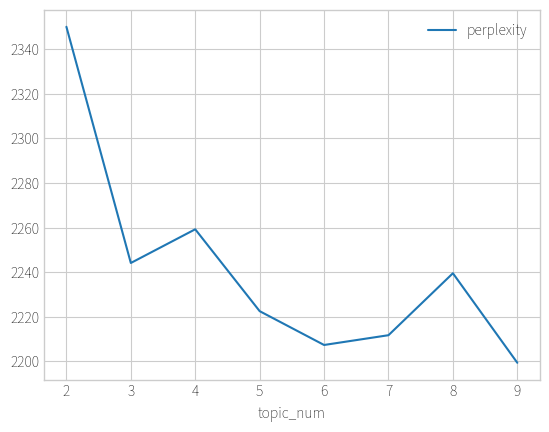

In [26]:
result.plot.line(x='topic_num', y='perplexity')

<Axes: xlabel='topic_num'>

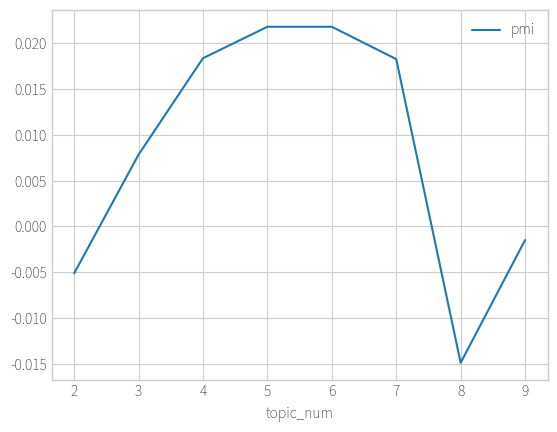

In [27]:
result.plot.line(x='topic_num', y='pmi')

In [28]:
best_model = LdaModel(
    corpus = corpus,
    num_topics = 6,
    id2word=dictionary,
    random_state = 1500,
    passes = 20
    )

#### 視覺化

In [29]:
pyLDAvis.enable_notebook()
p = pyLDAvis.gensim_models.prepare(best_model, corpus, dictionary)
p

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
4      0.030201 -0.025764       1        1  26.788641
3     -0.109369  0.172102       2        1  22.479596
2      0.032888 -0.119407       3        1  19.675648
0     -0.038611 -0.186632       4        1  13.777203
1     -0.173500  0.057755       5        1   9.505447
5      0.258391  0.101947       6        1   7.773464, topic_info=    Term         Freq         Total Category  logprob  loglift
189   川普  6169.000000   6169.000000  Default  30.0000  30.0000
74    中國  2330.000000   2330.000000  Default  29.0000  29.0000
279   石油  1131.000000   1131.000000  Default  28.0000  28.0000
295   美軍  2736.000000   2736.000000  Default  27.0000  27.0000
7    以色列  4290.000000   4290.000000  Default  26.0000  26.0000
..   ...          ...           ...      ...      ...      ...
291   經濟   169.336731    651.181808   Topic6  -5.1598   1.2076
434   攻擊   249.845388   2727.549040   Topic6  -4.7708   0.1641
47    美國   335.337347  10792.593617   Topic6  -4.4765  -0.9170
74    中國   231.928195   2330.888807   Topic6  -4.8452   0.2469
23    安全   169.303160    937.867297   Topic6  -5.1600   0.8425

[479 rows x 6 columns], token_table=      Topic      Freq Term
term                      
486       1  0.020740   一下
486       2  0.801944   一下
486       3  0.017283   一下
486       5  0.134810   一下
486       6  0.024197   一下
...     ...       ...  ...
7759      5  0.975021   魷魚
8055      5  0.993348   鵝肝
853       1  0.018333  黎巴嫩
853       3  0.979485  黎巴嫩
854       3  0.959234   齊射

[1100 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[5, 4, 3, 1, 2, 6])

#### Topic 1: 外交與美方動態 Topic 2: 兩岸觀點 Topic 3: 伊以對抗 Topic 4: 武裝與裝備 Topic 5: 東亞相關 Topic 6: 能源經濟

In [30]:
pyLDAvis.save_html(p, "lda_zh.html")

#### Guidedlda

In [31]:
import guidedlda

In [32]:
word2id = dictionary.token2id

In [33]:
seed_topic_list = [
    ["以色列", "德黑蘭", "黎巴嫩", "伊斯蘭", "加薩"],           # 主題 0: 中東衝突核心
    ["戰爭", "攻擊", "飛彈", "無人機", "空襲", "攔截"],         # 主題 1: 軍事行動與攻防
    ["川普", "拜登", "談判", "協議", "停火", "外交"],           # 主題 2: 外交斡旋與美方立場
    ["美國", "中國", "台灣", "俄羅斯", "烏克蘭", "中共"],       # 主題 3: 國際地緣政治與兩岸
    ["石油", "能源", "油價", "荷姆茲海峽", "封鎖", "原油"],     # 主題 4: 能源與全球經濟影響
    ["報導", "消息", "記者", "影片", "大紀元", "中央社"]        # 主題 5: 媒體來源與訊息流向
]

In [34]:
# 檢查「伊朗」是否存在
print('伊朗' in word2id)

# 如果想看前 50 個詞
print(list(word2id.keys())[:50])

False
['上空', '中央社', '主場', '人員', '今日', '代表', '代表團', '以色列', '伊斯蘭', '保護', '停戰', '出動', '出處', '前往', '加強', '加油機', '南部', '印度', '和平', '外媒', '外電', '大批', '大量', '安全', '專家', '小時', '巴基斯坦', '巴德', '延長', '想必', '戰機', '披露', '摘要', '摧毀', '數據', '架次', '殆盡', '波斯灣', '派出', '消耗', '監控', '確保', '稱為', '空中', '空域', '空軍', '綜合', '美國', '舉行', '航程']


#### 建立種子詞字典

In [35]:
seed_topics = {}
for t_id, st in enumerate(seed_topic_list):
    for word in st:
        if word in word2id:
            seed_topics[word2id[word]] = t_id
        else:
            # 沒找到就跳過，並印出提醒
            print(f"提示：詞彙 '{word}' 已被過濾，不加入種子引導。")

# 檢查一下最後成功的種子數量
print(f"成功對應的種子詞數量: {len(seed_topics)}")

提示：詞彙 '報導' 已被過濾，不加入種子引導。
提示：詞彙 '消息' 已被過濾，不加入種子引導。
提示：詞彙 '影片' 已被過濾，不加入種子引導。
成功對應的種子詞數量: 32


In [36]:
X = corpus2dense(corpus, len(dictionary), len(corpus)).T.astype(np.int64)

#### 訓練引導式模型

In [37]:
model = guidedlda.GuidedLDA(n_topics=6, n_iter=100, random_state=7, refresh=20)
model.fit(X, seed_topics=seed_topics, seed_confidence=1)

INFO:guidedlda:n_documents: 3547
INFO:guidedlda:vocab_size: 8352
INFO:guidedlda:n_words: 379315
INFO:guidedlda:n_topics: 6
INFO:guidedlda:n_iter: 100
INFO:guidedlda:<0> log likelihood: -3797863
INFO:guidedlda:<20> log likelihood: -3093098
INFO:guidedlda:<40> log likelihood: -3067267
INFO:guidedlda:<60> log likelihood: -3057532
INFO:guidedlda:<80> log likelihood: -3052282
INFO:guidedlda:<99> log likelihood: -3050704


#### 結果

In [38]:
# 整理／顯示主題模型結果
n_top_words = 10
topic_word = model.topic_word_
# 取得corpus全部的詞彙表
vocab = tuple(dictionary.token2id.keys())

for i, topic_dist in enumerate(topic_word):
    # 依照詞語機率從小到大排序，找出每個主題的前十個關鍵詞
    topic_words = np.array(vocab)[np.argsort(topic_dist)][: -(n_top_words + 1) : -1]
    print("Topic {}: {}".format(i, " ".join(topic_words)))
    

doc_topic = model.doc_topic_ # 文件-主題 分佈
term_freq = tuple(dictionary.cfs.values()) # 每個詞在整個語料中出現的總次數
doc_len = [sum(v for k, v in doc) for doc in corpus] # 每篇文章的長度

## LDAvis
pyLDAvis.enable_notebook()
p = pyLDAvis.prepare(topic_word, doc_topic, doc_len, vocab = vocab, term_frequency = term_freq)
p

Topic 0: 以色列 攻擊 美國 革命衛隊 發動 打擊 設施 空襲 部隊 真主黨
Topic 1: 美軍 飛彈 無人機 美國 系統 攻擊 基地 目標 打擊 防空
Topic 2: 川普 美國 戰爭 總統 談判 官員 軍事 協議 以色列 結束
Topic 3: 美國 中國 川普 台灣 戰爭 以色列 知道 世界 根本 中東
Topic 4: 石油 中國 美國 能源 全球 海峽 荷姆茲海峽 經濟 船隻 美元
Topic 5: 哈米尼 中共 記者 政權 中國 民眾 領袖 軍事 國際 總統


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2      0.009467  0.064580       1        1  25.151906
3     -0.047413  0.053250       2        1  21.296144
1      0.193377  0.069100       3        1  16.421895
0      0.123068  0.099508       4        1  13.345536
4      0.032901 -0.327888       5        1  12.244197
5     -0.311400  0.041450       6        1  11.540323, topic_info=    Term         Freq        Total Category  logprob  loglift
189   川普  6142.000000  6142.000000  Default  30.0000  30.0000
7    以色列  4389.000000  4389.000000  Default  29.0000  29.0000
295   美軍  2778.000000  2778.000000  Default  28.0000  28.0000
263  無人機  1616.000000  1616.000000  Default  27.0000  27.0000
386   飛彈  2047.000000  2047.000000  Default  26.0000  26.0000
..   ...          ...          ...      ...      ...      ...
23    安全   151.783423   936.836989   Topic6  -5.6643   0.3393
466   關係   124.823667   381.518413   Topic6  -5.8599   1.0421
8    伊斯蘭   138.802800   683.096936   Topic6  -5.7537   0.5657
99    英國   114.838573   281.644407   Topic6  -5.9433   1.2622
24    專家   116.835592   414.517907   Topic6  -5.9260   0.8930

[456 rows x 6 columns], token_table=      Topic      Freq  Term
term                       
486       2  0.898317    一下
486       4  0.033271    一下
486       5  0.069869    一下
2410      4  0.999597  一廂情願
488       3  1.000869    一架
...     ...       ...   ...
6142      3  1.000363    魚雷
8055      2  1.001183    鵝肝
853       1  0.019936   黎巴嫩
853       2  0.008860   黎巴嫩
853       4  0.970211   黎巴嫩

[784 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 4, 2, 1, 5, 6])

#### Topic 1: 美國動態 Topic 2: 地緣政治 Topic 3: 軍事行動 Topic 4: 伊以對抗 Topic 5: 能源經濟 Topic 6: 政權穩定

#### 文本主題機率

In [39]:
doc_topic_dist = model.doc_topic_

# 檢查一下形狀，預期應該是 (3547, 6)
print(f"分佈矩陣形狀: {doc_topic_dist.shape}")

# 如果你想看第一篇文章在 6 個主題的分機率：
print(f"第一篇文章的主題分佈: \n{doc_topic_dist[0]}")

分佈矩陣形狀: (3547, 6)
第一篇文章的主題分佈: 
[0.19442902 0.45354433 0.23144549 0.07412549 0.03710901 0.00934666]


In [41]:
doc_topic[100]

array([1.02113733e-01, 3.00246202e-05, 8.55731700e-01, 3.00246202e-05,
       4.20644929e-02, 3.00246202e-05])

In [45]:
m_theta = doc_topic_dist 

ptt_clean['topic_label'] = m_theta.argmax(axis=1) + 1

print(ptt_clean['topic_label'].value_counts())

topic_label
4    1630
3     716
2     453
1     308
5     254
6     186
Name: count, dtype: int64


In [48]:
ptt_clean.head()

,content_clean,artUrl,artCatagory,artDate,words,topic_label
0,新聞出處 新聞內容摘要 中央社新德里日綜合外電報導 美國與伊朗將於日在巴基斯坦首都伊斯蘭馬巴德舉行 萬眾矚目的談判 外媒披露 巴基斯坦空軍出動大批各式軍機到波斯灣空域 保護伊朗代表 團前來赴會 今日印度報 報導 巴基斯坦為確保安全而...,https://www.ptt.cc/bbs/Military/M.1775823165.A.7A5.html,Military,2026-04-10 20:12:41,"[保護, 伊朗, 人員, 前來, 巴基斯坦, 空軍, 安全, 出處, 摘要, 中央社, 新德里, 綜合, 外電, 美國, 伊朗, 將於日, 巴基斯坦, 首都, 伊斯蘭, 巴德, 舉行, 萬眾矚目, 談判, 外媒, 披露, 巴基斯坦,...",2
1,根據 的統整各間民調 可見美國民眾對伊朗戰爭的支持度持續下滑 皮尤民調 追蹤美國民眾對以色列和納坦雅胡的支持度 顯示美國民眾越來越厭惡以色列和納坦雅胡 天空新聞 民調顯示從去年年底到現在 英國民眾認為美國是世界上的負面力量的比例達 ...,https://www.ptt.cc/bbs/Military/M.1775809255.A.D32.html,Military,2026-04-10 16:20:52,"[幾則, 伊朗, 戰爭, 民調, 統整, 各間, 民調, 美國, 民眾, 伊朗, 戰爭, 支持度, 下滑, 民調, 追蹤, 美國, 民眾, 以色列, 納坦雅胡, 支持度, 美國, 民眾, 越來越, 厭惡, 以色列, 納坦雅胡, 天空...",6
2,大西洋期刊 我對這篇文章不予置評 僅供參考 中國從伊朗戰爭中學到了什麼 對台灣實施封鎖 對全球經濟造成的衝擊 將比伊朗封鎖荷姆茲海峽更為嚴重 中國可以從這場伊朗戰爭中學到許多 美國劃下的紅線與期限 即使伴隨著種族滅絕的威 脅 也可能...,https://www.ptt.cc/bbs/Military/M.1775807658.A.5CA.html,Military,2026-04-10 15:54:15,"[大西洋, 期刊, 中國, 伊朗, 戰爭, 學到, 大西洋, 期刊, 這篇, 不予置評, 參考, 中國, 伊朗, 戰爭, 中學, 台灣, 實施, 封鎖, 全球, 經濟, 衝擊, 將比, 伊朗, 封鎖, 荷姆茲海峽, 嚴重, 中國, ...",5
3,以色列媒體報導 以色列軍方告訴國會議員說伊朗的新政府比戰前的更極端 以色列軍方另稱作戰對伊朗造成嚴重打擊 但是伊朗已經開始著手恢復飛彈生產等能力 別把我的肖像掛在你們的辦公室裡 掛上你們孩子的照片 在做每一個決定之前 先看看他們的眼睛,https://www.ptt.cc/bbs/Military/M.1775806937.A.68F.html,Military,2026-04-10 15:42:14,"[以色列, 軍方, 伊朗, 以色列, 以色列, 軍方, 國會, 議員, 伊朗, 戰前, 以色列, 軍方, 另稱, 作戰, 伊朗, 嚴重, 打擊, 伊朗, 著手, 恢復, 飛彈, 生產, 能力, 肖像, 掛在, 辦公室, 掛上, 孩子...",3
4,曾揚言發展核武 伊朗前外長哈拉齊遇襲亡 住所遭攻擊妻也罹難 伊朗媒體報導 前伊朗外交部長哈拉濟 月日在美國與以色列的空襲 中受傷 今天傷重不治 哈拉濟曾表示德黑蘭可能會尋求發展核武 法新社報導 歲的哈拉濟生前在隸屬於伊朗外交部的外交...,https://www.ptt.cc/bbs/Military/M.1775801379.A.454.html,Military,2026-04-10 14:09:37,"[曾嗆, 發展, 核武, 伊朗, 外長, 傷重, 不治, 揚言, 發展, 核武, 伊朗, 外長, 拉齊, 遇襲, 住所, 攻擊, 罹難, 伊朗, 伊朗, 外交部長, 哈拉, 美國, 以色列, 空襲, 受傷, 傷重, 不治, 哈拉, ...",1


In [49]:
ptt_clean.groupby(ptt_clean['artDate'].dt.date)['topic_label'].value_counts(normalize=True)

artDate     topic_label
2026-03-01  4              0.571429
            1              0.142857
            2              0.100000
            6              0.089286
            3              0.078571
                             ...   
2026-04-10  5              0.200000
            6              0.200000
            1              0.100000
            4              0.100000
            2              0.050000
Name: proportion, Length: 240, dtype: float64

In [50]:
date_topic = ptt_clean.groupby(ptt_clean['artDate'].dt.date)['topic_label'].value_counts(normalize=True).unstack()
date_topic.head()

topic_label,1,2,3,4,5,6
artDate,,,,,,
2026-03-01,0.142857,0.100000,0.078571,0.571429,0.017857,0.089286
2026-03-02,0.102767,0.130435,0.098814,0.588933,0.035573,0.043478
2026-03-03,0.059459,0.102703,0.189189,0.486486,0.064865,0.097297
2026-03-04,0.128378,0.182432,0.128378,0.445946,0.040541,0.074324
2026-03-05,0.120690,0.206897,0.163793,0.413793,0.025862,0.068966


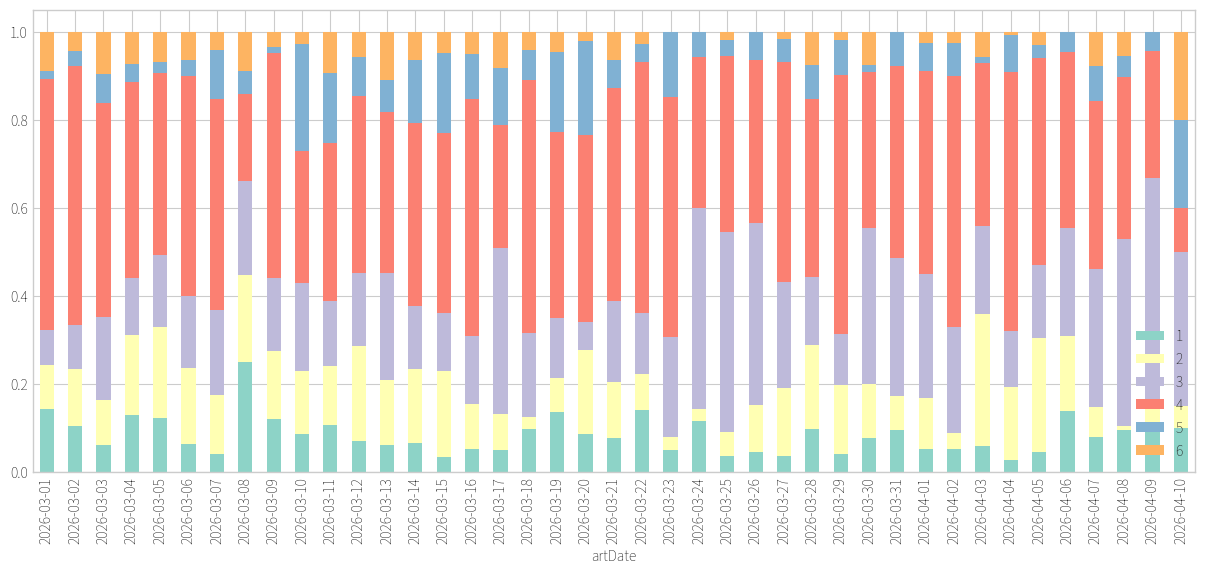

In [51]:
fig, ax = plt.subplots(figsize=(15, 6))
date_topic.plot.bar(ax=ax, stacked=True, color = plt.cm.Set3.colors)
ax.legend(loc='lower right')

#### 本研究透過 Guided LDA 發現，PTT 在中東衝突中扮演了 『地緣政治解讀器』 的角色。從時序分佈來看，伊以對抗（主題 4） 提供了討論的基礎動能，而 地緣政治（主題 2） 則是熱度持久的關鍵。每當發生 軍事行動（主題 3） 的脈衝式爆發後，往往會帶動 美國動態（主題 1） 與 能源經濟（主題 5） 的後續討論。這證明了 PTT 使用者具備高度的資訊串聯能力，能從單一軍事事件演繹出全球性的政治經濟分析。